# 03 描述統計 — Descriptive Statistics
**Research Question: Sleep and SadOrHopeless**

- **Group variable:** `SadOrHopeless`
- **Response variable:** `Sleep`
- **Method:** Descriptive Statistics and Visualization


## 1. 載入套件與資料 | Load Libraries & Data

In [2]:
import os
import pandas as pd

# 1. 強制讓 Python 切換到你的檔案所在目錄
target_dir = r"C:\Users\88690\OneDrive\桌面\cycle4-main\data\Processes"
os.chdir(target_dir)

# 2. 確認切換成功，並直接用「檔名」讀取
print("目前工作目錄已切換至：", os.getcwd())

df = pd.read_csv('YRBS_2007_sleep_sad_clean.csv')

# 3. 顯示結果
print('資料維度 Shape:', df.shape)
display(df[['Sleep','SadOrHopeless']].head(10))

目前工作目錄已切換至： C:\Users\88690\OneDrive\桌面\cycle4-main\data\Processes
資料維度 Shape: (12106, 2)


,Sleep,SadOrHopeless
0,5.0,1.0
1,4.0,2.0
2,1.0,1.0
3,1.0,1.0
4,6.0,2.0
5,5.0,2.0
6,5.0,2.0
7,5.0,2.0
8,5.0,2.0
9,5.0,2.0


## 2. 變數探索 | Variable Exploration

In [3]:
print('=== Sleep 原始分布 ===')
print(df['Sleep'].value_counts(dropna=False).sort_index())

print()
print('=== SadOrHopeless 原始分布 ===')
print(df['SadOrHopeless'].value_counts(dropna=False))


=== Sleep 原始分布 ===
Sleep
1.0     754
2.0    1240
3.0    2729
4.0    3614
5.0    2779
6.0     740
7.0     250
Name: count, dtype: int64

=== SadOrHopeless 原始分布 ===
SadOrHopeless
2.0    8525
1.0    3581
Name: count, dtype: int64


## 3. 資料重編碼 | Recoding

**規則:**
- `Sleep`: 保留原始睡眠時數
- `SadOrHopeless`: 1 = Yes, 2 = No


In [4]:
df_clean = df[['Sleep','SadOrHopeless']].copy()

df_clean = df_clean.dropna()

df_clean = df_clean[df_clean['Sleep'].between(1,7)]
df_clean = df_clean[df_clean['SadOrHopeless'].isin([1,2])]

df_clean['sad_label'] = np.where(
    df_clean['SadOrHopeless']==1,
    'Yes',
    'No'
)

print(df_clean.shape)
df_clean.head()


(12106, 3)


,Sleep,SadOrHopeless,sad_label
0,5.0,1.0,Yes
1,4.0,2.0,No
2,1.0,1.0,Yes
3,1.0,1.0,Yes
4,6.0,2.0,No


## 4. 描述統計摘要表 | Descriptive Summary Table

In [5]:
summary = (
    df_clean.groupby('sad_label')['Sleep']
    .agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        minimum='min',
        maximum='max'
    )
    .round(2)
)

summary.index.name='SadOrHopeless'

print('=== 描述統計摘要表 ===')
print(summary.to_string())


=== 描述統計摘要表 ===
                  n  mean  median   std  minimum  maximum
SadOrHopeless                                            
No             8525  3.93     4.0  1.28      1.0      7.0
Yes            3581  3.48     4.0  1.44      1.0      7.0


## 5. 視覺化 | Visualization
### 5a. Bar Chart — 平均睡眠時數比較


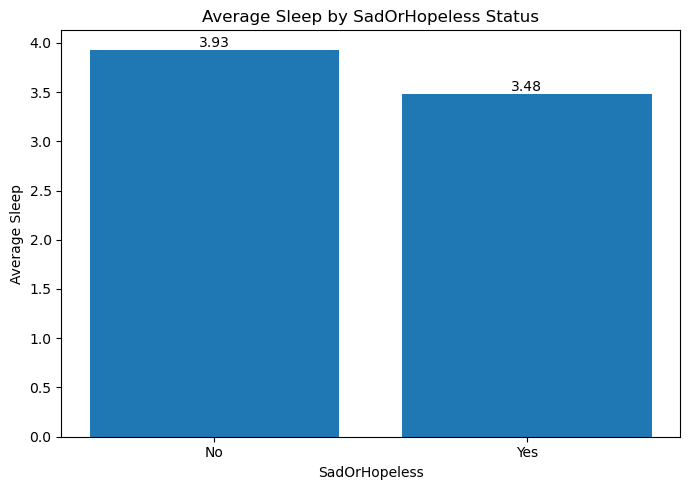

In [6]:
fig, ax = plt.subplots(figsize=(7,5))

groups = summary.index.tolist()
means = summary['mean'].tolist()

bars = ax.bar(groups, means)

for bar, value in zip(bars, means):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value+0.03,
        f'{value:.2f}',
        ha='center'
    )

ax.set_ylabel('Average Sleep')
ax.set_xlabel('SadOrHopeless')
ax.set_title('Average Sleep by SadOrHopeless Status')

plt.tight_layout()
plt.show()


### 5b. Boxplot — 睡眠分布比較

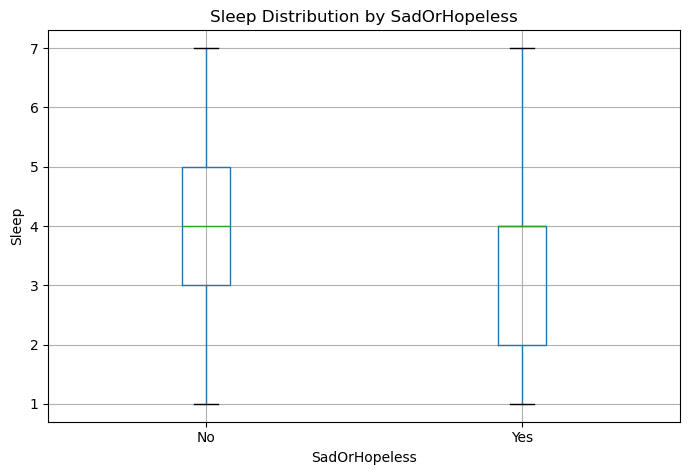

In [7]:
fig, ax = plt.subplots(figsize=(7,5))

df_clean.boxplot(
    column='Sleep',
    by='sad_label',
    ax=ax
)

ax.set_title('Sleep Distribution by SadOrHopeless')
ax.set_xlabel('SadOrHopeless')
ax.set_ylabel('Sleep')

plt.suptitle('')
plt.tight_layout()
plt.show()


## 6. 儲存摘要表 | Save Summary Table

In [8]:
summary.to_csv('descriptive_summary_sleep_by_sad.csv')

print('摘要表已儲存')
print()
print('=== 描述統計完成。下一步: 04_inference.ipynb ===')


摘要表已儲存

=== 描述統計完成。下一步: 04_inference.ipynb ===
